In [1]:
import numpy as np

# ── The stored pattern pairs ─────────────────────────────────────────────
# We are memorizing TWO associations:
#
#   Pair 1:  X[0] = [1,  1,  1, -1]  ↔  Y[0] = [1, -1]
#   Pair 2:  X[1] = [-1, -1, 1,  1]  ↔  Y[1] = [-1, 1]
#
# Think of X patterns as 4-bit inputs and Y patterns as 2-bit outputs.
# Values are +1 or -1 (bipolar), NOT 0 and 1.

X = np.array([[ 1,  1,  1, -1],   # Pattern A (input side)
              [-1, -1,  1,  1]])   # Pattern B (input side)

Y = np.array([[ 1, -1],           # Pattern A (output side)
              [-1,  1]])           # Pattern B (output side)

# ── Step 1: Build the Weight Matrix ──────────────────────────────────────
# The weight matrix W encodes ALL the associations at once.
# Formula:  W = Y^T · X   (outer product sum of all pairs)
#
# Y.T is shape (2×2), X is shape (2×4), so W is shape (2×4)
# Each pair contributes one outer product to W — this is Hebbian learning:
# "neurons that fire together, wire together"

W = np.dot(Y.T, X)
print("Weight matrix W:")
print(W)
# W = [[ 2,  2,  0, -2],
#      [-2, -2,  0,  2]]

# ── Step 2: The BAM recall function ──────────────────────────────────────
# Given an input x (4-bit), compute the associated y (2-bit)
# Formula: y = sign(W · x)
# np.sign: +1 if positive, -1 if negative

def recall(x):
    return np.sign(np.dot(W, x))

# ── Step 3: Test with a noisy/partial input ───────────────────────────────
# Original Pattern A input was: [ 1,  1,  1, -1]
# Our test input is:             [ 1, -1, -1, -1]  ← 2 bits are flipped!
#
# Can BAM still recall the correct Y pattern despite the noise?

x_test = np.array([1, -1, -1, -1])
y_test = recall(x_test)

print("\nStored Pattern A — x:", X[0], "→ y:", Y[0])
print("Noisy test input  — x:", x_test)
print("BAM recalled      — y:", y_test)
print("\nRecall successful?", np.array_equal(y_test, Y[0]))

Weight matrix W:
[[ 2  2  0 -2]
 [-2 -2  0  2]]

Stored Pattern A — x: [ 1  1  1 -1] → y: [ 1 -1]
Noisy test input  — x: [ 1 -1 -1 -1]
BAM recalled      — y: [ 1 -1]

Recall successful? True


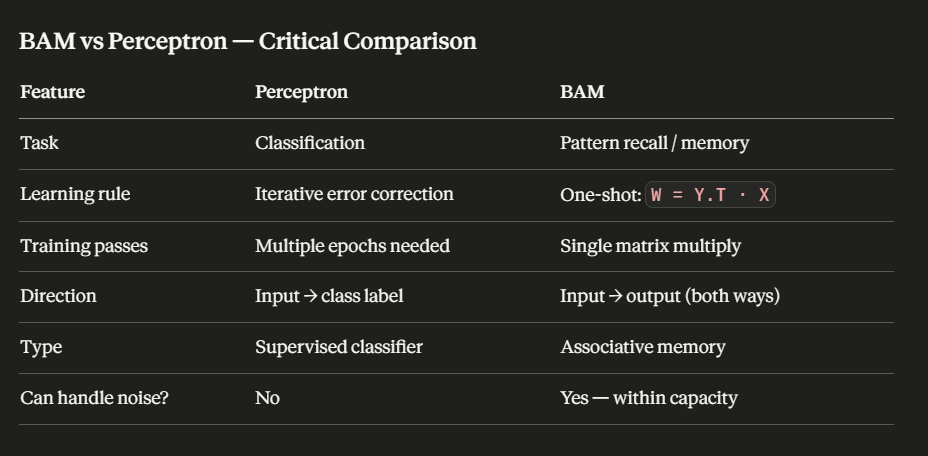

Exam Questions to Expect
Q1. What does BAM stand for and who proposed it?
Bidirectional Associative Memory, proposed by Bart Kosko in 1988.

Q2. How is the weight matrix computed in BAM?
W = Y.T · X — the transpose of Y dot-multiplied with X. This is a sum of outer products of each stored pair, which is Hebbian learning — connections between simultaneously active neurons are strengthened.

Q3. Why are ±1 values used instead of 0/1?
Bipolar values make the math symmetric and clean. With 0/1, a 0-valued bit contributes nothing to the dot product. With ±1, every bit actively participates — a −1 actively suppresses, a +1 actively excites.

Q4. What is the storage capacity of BAM?
A BAM with n input neurons and m output neurons can reliably store approximately min(n, m) pattern pairs. Beyond that, patterns start interfering with each other and recall becomes unreliable.

Q5. What makes BAM "bidirectional"?
You can recall in both directions. Given X, compute Y = sign(W · X). Given Y, compute X = sign(W.T · Y). The same weight matrix W works for retrieval in both directions — just transpose it for the reverse direction.

Q6. How is BAM different from a Hopfield Network?
A Hopfield Network is autoassociative — you give it a noisy version of a pattern and it recalls the same pattern (X → X). BAM is heteroassociative — it maps between two different pattern spaces (X → Y). BAM is essentially a two-layer generalization of the Hopfield Network.